# Lendo a base de dados e fazendo validações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [2]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,cotacao_dia_sep_500,cotacao_petroleo
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109,6861.89,71.27
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359,6881.31,69.77
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196,6836.17,67.75
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120,6832.76,67.52
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836,6941.47,69.40


In [3]:
ibovespa[["abertura", "maxima", "minima", "fechamento", "variacao_percentual"]].describe()

,abertura,maxima,minima,fechamento,variacao_percentual
count,534.000000,534.000000,534.000000,534.000000,534.000000
mean,135.653060,136.561036,134.888457,135.754279,0.067959
std,13.813322,14.069473,13.746830,14.000180,0.916199
min,118.534000,119.451000,118.223000,118.533000,-4.310000
25%,127.223000,127.871250,126.448750,127.227500,-0.447500
50%,131.168000,131.867500,130.424000,131.168500,0.050000
75%,138.852250,139.396500,137.987500,138.879750,0.590000
max,189.694000,190.561000,186.959000,189.699000,3.330000


# Feature Engineering

In [4]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,cotacao_dia_sep_500,cotacao_petroleo
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,5.2109,6861.89,71.27
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,5.2359,6881.31,69.77
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,5.2196,6836.17,67.75
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,5.2120,6832.76,67.52
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,5.1836,6941.47,69.40


In [5]:
# Renomeando a coluna 'data' para 'ds' para compatibilidade com alguns modelos
ibovespa.rename(columns={'data': 'ds'}, inplace=True)
ibovespa.sort_values(by='ds', inplace=True)

In [6]:
# Exibindo informações do DataFrame
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 533 to 0
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ds                   534 non-null    datetime64[us]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   cotacao_dia_dolar    534 non-null    float64       
 8   cotacao_dia_sep_500  519 non-null    float64       
 9   cotacao_petroleo     534 non-null    float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 41.8 KB


In [7]:
ibovespa["vol_log"] = np.log1p(ibovespa["vol_reais"]) # Transformação logarítmica para lidar com a alta variabilidade e normalizar a base de dados
ibovespa["range"] = (ibovespa["maxima"] - ibovespa["minima"]) / ibovespa["fechamento"] # Cálculo do range relativo para capturar a volatilidade diária

In [8]:
ibovespa["body"] = (ibovespa["fechamento"] - ibovespa["abertura"]) / ibovespa["abertura"] # Cálculo do corpo da vela para capturar a direção e intensidade do movimento diário
ibovespa["upper_shadow"] = (ibovespa["maxima"] - ibovespa["fechamento"]) / ibovespa["fechamento"] # Cálculo da sombra superior para capturar a pressão de venda durante o dia
ibovespa["lower_shadow"] = (ibovespa["fechamento"] - ibovespa["minima"]) / ibovespa["fechamento"] # Cálculo da sombra inferior para capturar a pressão de compra durante o dia

__Explicação das variáveis Body, Upper Shadow e Lower Shadow__

*Body* - O tamanho do corpo do candle em termos percentuais.
fechamento > abertura - body positivo (dia comprador)
fechamento < abertura - body negativo (dia vendedor)
muito próximo - indecisão

*upper_shadow* - Quanto o preço subiu acima do fechamento antes de recuar.
Se for grande: O mercado subiu bastante, mas perdeu força antes de fechar. Indica pressão vendedora no topo
Significa que houve rejeição no topo.

*lower_shadow* - Quanto o mercado caiu durante o dia mas recuperou antes de fechar.
Houve forte pressão vendedora intraday, mas compradores reagiram. Pode indicar suporte
Mostra recuperação forte.

In [9]:
# Calculando os retornos para os lags de 1, 2 e 3 dias e volatilidade
ibovespa["ret_1"] = ibovespa["variacao_percentual"] # Retorno do dia atual
ibovespa["ret_2"] = ibovespa["variacao_percentual"].shift(1) # Retorno do dia anterior (lag de 1 dia)
ibovespa["ret_3"] = ibovespa["variacao_percentual"].shift(2) # Retorno de dois dias atrás (lag de 2 dias)
ibovespa["volatility_5"] = ibovespa["ret_1"].rolling(5).std() # Volatilidade dos últimos 5 dias para capturar a instabilidade recente do mercado

In [10]:
# Definindo a variável alvo (target) com base na variação percentual futura
ibovespa["ret_futuro"] = ibovespa["variacao_percentual"].shift(-1)

ibovespa["status"] = np.where(ibovespa["ret_futuro"] > 0.000, 1,
        np.where(ibovespa["ret_futuro"] < -0.000, 0, np.nan))

ibovespa = ibovespa.dropna(subset=["status"])

__Variável Target__

Para criação da variável target, utilizando o retorno do dia seguinte no dia anterior, isso permite que consigamos prever o futuro usando dados do presente.

In [11]:
# Calculando indicadores de tendência de curto, médio e longo prazo

ibovespa["ret_2d"] = ibovespa["variacao_percentual"].rolling(2).sum() # Retorno acumulado dos últimos 2 dias para capturar a tendência de curto prazo do mercado
ibovespa["ret_3d_passado"] = ibovespa["variacao_percentual"].rolling(3).sum() # Retorno acumulado dos últimos 3 dias para capturar a tendência recente do mercado
ibovespa["ma_3"] = ibovespa["fechamento"].rolling(3).mean() # Média móvel de 3 dias para capturar a tendência de curto prazo
ibovespa["ma_10"] = ibovespa["fechamento"].rolling(10).mean() # Média móvel de 10 dias para capturar a tendência de médio prazo
ibovespa["trend"] = ibovespa["ma_3"] - ibovespa["ma_10"] # Indicador de tendência baseado na diferença entre as médias móveis de curto e médio prazo
ibovespa["ret_5"] = np.log(ibovespa["fechamento"] / ibovespa["fechamento"].shift(5)) # Retorno acumulado dos últimos 5 dias para capturar a tendência de médio prazo do mercado
ibovespa["vol_10"] = ibovespa["fechamento"].rolling(10).std() # Volatilidade dos últimos 10 dias para capturar a instabilidade do mercado em um horizonte de médio prazo

ibovespa["mm20"] = ibovespa["fechamento"].rolling(20).mean() # Média móvel de 20 dias para capturar a tendência de longo prazo
ibovespa["dist_mm20"] = (ibovespa["fechamento"] - ibovespa["mm20"]) / ibovespa["mm20"] # Distância relativa do preço de fechamento à média móvel de 20 dias para capturar a força da tendência de longo prazo
ibovespa["slope_mm20"] = (ibovespa["mm20"] - ibovespa["mm20"].shift(1)) / ibovespa["mm20"].shift(1) # Cálculo da inclinação da média móvel de 20 dias para capturar a direção e força da tendência de longo prazo

# Distância da MM50 (regime mais longo)
ibovespa["mm50"] = ibovespa["fechamento"].rolling(50).mean()
ibovespa["dist_mm50"] = (ibovespa["fechamento"] - ibovespa["mm50"]) / ibovespa["mm50"] # Distância relativa do preço de fechamento à média móvel de 50 dias para capturar a força da tendência de longo prazo em um horizonte mais extenso

ibovespa["ret_5"] = ibovespa["variacao_percentual"].rolling(5).sum() # Retorno acumulado dos últimos 5 dias para capturar a tendência de médio prazo do mercado

In [12]:
# Calculando os retornos logarítmicos para as variáveis de interesse em relação ao mercado internacional
ibovespa["ret_dolar"] = np.log1p(ibovespa['cotacao_dia_dolar'] / ibovespa['cotacao_dia_dolar'].shift(1)) # Retorno logarítmico do dólar para capturar a influência das variações cambiais no mercado brasileiro
ibovespa["ret_sp500"] = np.log1p(ibovespa['cotacao_dia_sep_500'] / ibovespa['cotacao_dia_sep_500'].shift(1)) # Retorno logarítmico do S&P 500 para capturar a influência das variações do mercado americano no mercado brasileiro
ibovespa["ret_petroleo"] = np.log1p(ibovespa['cotacao_petroleo'] / ibovespa['cotacao_petroleo'].shift(1)) # Retorno logarítmico do petróleo para capturar a influência das variações dos preços das commodities no mercado brasileiro

In [13]:
# Se exterior sobe e IBOV já está acima da média, probabilidade de continuação aumenta.
ibovespa["relacao_exterior"] = ibovespa["ret_sp500"]  * ibovespa["mm20"] # Indicador que combina o retorno do S&P 500 com a posição do IBOV em relação à sua média móvel de longo prazo para capturar a influência do mercado internacional na tendência do IBOV.

In [14]:
# Cálculo do gap entre a abertura do dia atual e o fechamento do dia anterior para capturar a influência de eventos ocorridos fora do horário de negociação
ibovespa["gap"] = (
    ibovespa["abertura"] - ibovespa["fechamento"].shift(1)
) / ibovespa["fechamento"].shift(1)

# sinal do gap
ibovespa["gap_sign"] = np.sign(ibovespa["gap"])  # 1 se positivo, -1 se negativo, 0 se zero

__GAP__:

No mercado financeiro, gap é a diferença entre: preço de abertura de hoje e preço de fechamento de ontem

Isso captura movimentos que ocorreram fora do pregão, por exemplo: notícias internacionais,	fechamento do S&P500, eventos macroeconômicos e	mercados asiáticos ou europeus.

# Removendo as linhas nulas e dropando as colunas que não agregam para o modelo

In [15]:
ibovespa = ibovespa.dropna()
ibovespa = ibovespa.reset_index(drop=True)
ibovespa = ibovespa.drop(columns=['ret_futuro', 'abertura', 'maxima', 'minima', 'fechamento', 'vol_reais', 'variacao_percentual', 'ma_3', 'ma_10', 'cotacao_dia_dolar', 'cotacao_dia_sep_500', 'cotacao_petroleo', 'mm20', 'mm50',
                                'slope_mm20', 'ret_5', 'vol_10', 'dist_mm50', 'ret_3d_passado', 'ret_1', 'ret_2', 'body', 'range', 'lower_shadow', 'upper_shadow', 'ret_petroleo'])
# ibovespa = ibovespa[["ds", "vol_log", "trend", "dist_mm20", "status"]]

In [16]:
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ds                458 non-null    datetime64[us]
 1   vol_log           458 non-null    float64       
 2   ret_3             458 non-null    float64       
 3   volatility_5      458 non-null    float64       
 4   status            458 non-null    float64       
 5   ret_2d            458 non-null    float64       
 6   trend             458 non-null    float64       
 7   dist_mm20         458 non-null    float64       
 8   ret_dolar         458 non-null    float64       
 9   ret_sp500         458 non-null    float64       
 10  relacao_exterior  458 non-null    float64       
 11  gap               458 non-null    float64       
 12  gap_sign          458 non-null    float64       
dtypes: datetime64[us](1), float64(12)
memory usage: 46.6 KB


In [17]:
print(ibovespa.corr()["status"].sort_values())

ret_2d             -0.028877
gap_sign           -0.012544
ret_dolar          -0.012460
volatility_5        0.014703
ret_sp500           0.018743
ret_3               0.029437
gap                 0.032162
relacao_exterior    0.035179
dist_mm20           0.041240
trend               0.059569
vol_log             0.085847
ds                  0.091804
status              1.000000
Name: status, dtype: float64


__Variáveis explicativas usadas no modelo__:

* ret_2d e ret_3 (acumulação recente de retorno)
* gap e gap_sign (abertura vs fechamento do dia anterior)
* ret_dolar e ret_sp500 (influência externa)
* volatility_5, vol_log (volatilidade de curto prazo)
* dist_mm20 (distância da média móvel)
* trend, relacao_exterior (movimento de mercado e relação externa)

Estatisticamente, a correlação com o status é baixa a moderada, mas juntas essas features permitem que modelos como o KNN forme clusters que diferenciam alta e baixa.

In [18]:
ibovespa.head()

,ds,vol_log,ret_3,volatility_5,status,ret_2d,trend,dist_mm20,ret_dolar,ret_sp500,relacao_exterior,gap,gap_sign
0,2024-03-13,15.994798,-0.75,0.892788,0.0,1.48,-0.807800,-0.006691,0.692966,0.692184,89.200599,0.000000,0.0
1,2024-03-14,16.044449,1.22,0.881629,0.0,0.01,-0.152800,-0.009099,0.695107,0.691711,89.135593,-0.000109,-1.0
2,2024-03-15,16.522894,0.26,0.823875,1.0,-0.99,-0.217667,-0.015698,0.693688,0.689900,88.833896,-0.000063,-1.0
3,2024-03-18,16.167838,-0.25,0.725927,1.0,-0.57,-0.429633,-0.013254,0.696186,0.696301,89.585593,0.000126,1.0
4,2024-03-19,16.229637,-0.74,0.476099,1.0,0.62,-0.426400,-0.007864,0.693625,0.695968,89.459630,0.000008,1.0


# Treinando o modelo

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [20]:
# Dividindo os dados em conjunto de treino e teste
train = ibovespa.iloc[:-30]
test = ibovespa.iloc[-30:]

In [21]:
# Separando as variáveis independentes (X) e a variável dependente (y) para treino e teste
X_train = train.drop(columns=['ds', 'status'])
X_test = test.drop(columns=['ds', 'status'])

y_train = train['status']
y_test = test['status']

In [22]:
# Baseline
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"O Baseline (classe majoritária) da nossa base de teste é de: {baseline:.4f}")

O Baseline (classe majoritária) da nossa base de teste é de: 0.6000


In [23]:
print(f" As datas de treino do modelo estão entre {min(train['ds'])} e {max(train['ds'])}, tendo {train.shape[0]} dias de dados.")
print(f" As datas de validação do modelo estão entre {min(test['ds'])} e {max(test['ds'])}, tendo {test.shape[0]} dias de dados.")

 As datas de treino do modelo estão entre 2024-03-13 00:00:00 e 2025-12-30 00:00:00, tendo 428 dias de dados.
 As datas de validação do modelo estão entre 2026-01-02 00:00:00 e 2026-02-18 00:00:00, tendo 30 dias de dados.


In [24]:
print(f"Base de treino:")
X_train.head()

Base de treino:


,vol_log,ret_3,volatility_5,ret_2d,trend,dist_mm20,ret_dolar,ret_sp500,relacao_exterior,gap,gap_sign
0,15.994798,-0.75,0.892788,1.48,-0.807800,-0.006691,0.692966,0.692184,89.200599,0.000000,0.0
1,16.044449,1.22,0.881629,0.01,-0.152800,-0.009099,0.695107,0.691711,89.135593,-0.000109,-1.0
2,16.522894,0.26,0.823875,-0.99,-0.217667,-0.015698,0.693688,0.689900,88.833896,-0.000063,-1.0
3,16.167838,-0.25,0.725927,-0.57,-0.429633,-0.013254,0.696186,0.696301,89.585593,0.000126,1.0
4,16.229637,-0.74,0.476099,0.62,-0.426400,-0.007864,0.693625,0.695968,89.459630,0.000008,1.0


## Regressão Logística

In [25]:
# Padronização dos dados usando StandardScaler, Scaler aprende média e desvio padrão
scaler = StandardScaler()

# Ajusta só no treino
x_train_scaled = scaler.fit_transform(X_train)

# Aplica a transformação no teste
x_test_scaled = scaler.transform(X_test)

### Fitando o modelo

In [26]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [27]:
# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.5333333333333333

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.25      0.08      0.12        12
         1.0       0.58      0.83      0.68        18

    accuracy                           0.53        30
   macro avg       0.41      0.46      0.40        30
weighted avg       0.45      0.53      0.46        30



In [28]:
print("Acurácia treino:", accuracy_score(y_train, model.predict(x_train_scaled)))
print("Acurácia teste:", accuracy_score(y_test, model.predict(x_test_scaled)))

Acurácia treino: 0.5560747663551402
Acurácia teste: 0.5333333333333333


## KNN

ROC AUC: 0.75


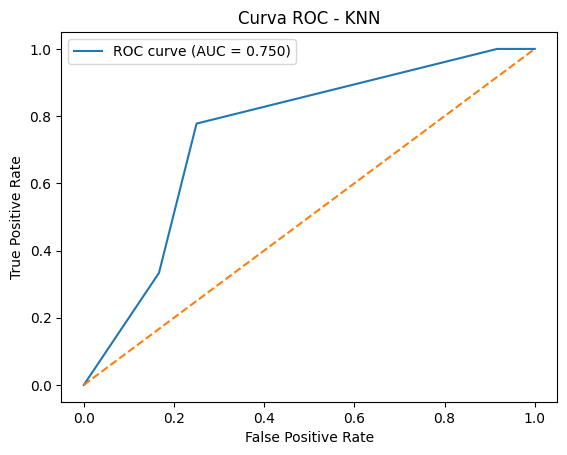

K=5, Threshold=0.45 → 0.7667

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72        12
         1.0       0.82      0.78      0.80        18

    accuracy                           0.77        30
   macro avg       0.76      0.76      0.76        30
weighted avg       0.77      0.77      0.77        30

ROC AUC: 0.75


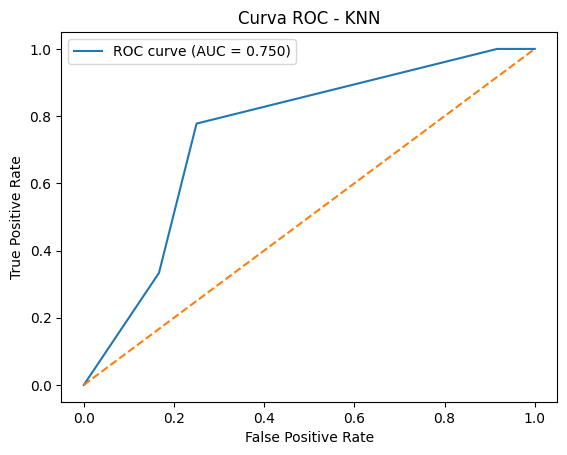

K=5, Threshold=0.5 → 0.7667

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72        12
         1.0       0.82      0.78      0.80        18

    accuracy                           0.77        30
   macro avg       0.76      0.76      0.76        30
weighted avg       0.77      0.77      0.77        30

ROC AUC: 0.75


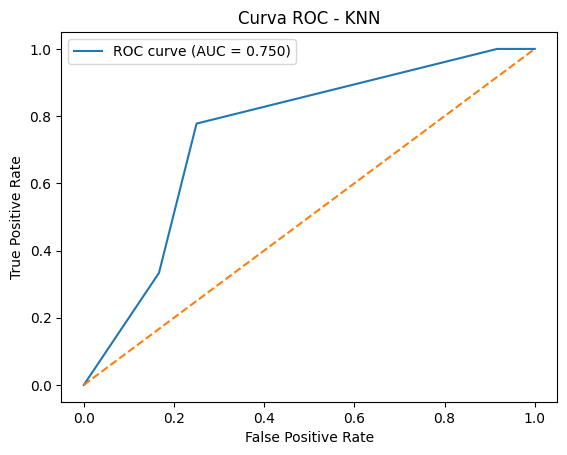

K=5, Threshold=0.55 → 0.7667

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72        12
         1.0       0.82      0.78      0.80        18

    accuracy                           0.77        30
   macro avg       0.76      0.76      0.76        30
weighted avg       0.77      0.77      0.77        30

ROC AUC: 0.75


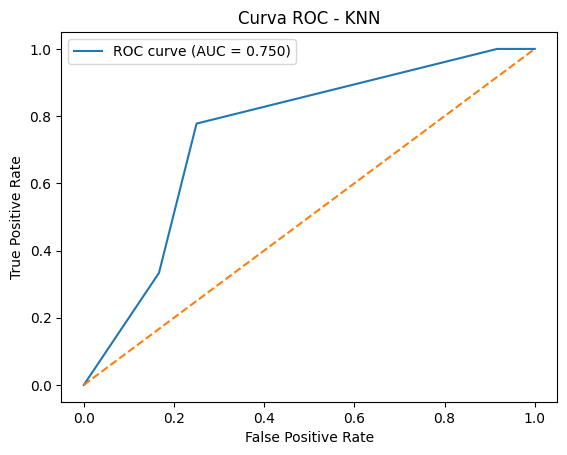

K=5, Threshold=0.6 → 0.7667

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72        12
         1.0       0.82      0.78      0.80        18

    accuracy                           0.77        30
   macro avg       0.76      0.76      0.76        30
weighted avg       0.77      0.77      0.77        30

ROC AUC: 0.7685185185185185


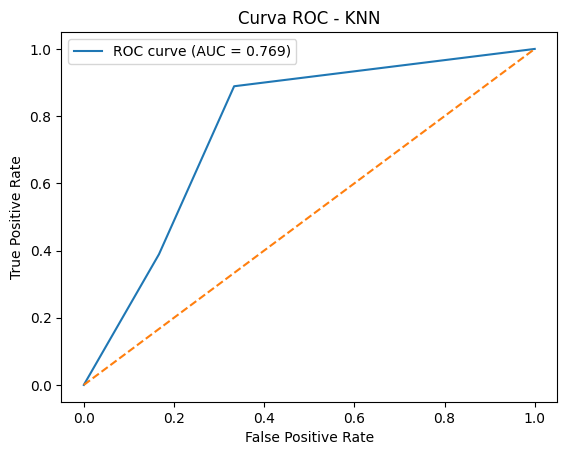

K=7, Threshold=0.45 → 0.8000

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.80      0.67      0.73        12
         1.0       0.80      0.89      0.84        18

    accuracy                           0.80        30
   macro avg       0.80      0.78      0.78        30
weighted avg       0.80      0.80      0.80        30

ROC AUC: 0.7685185185185185


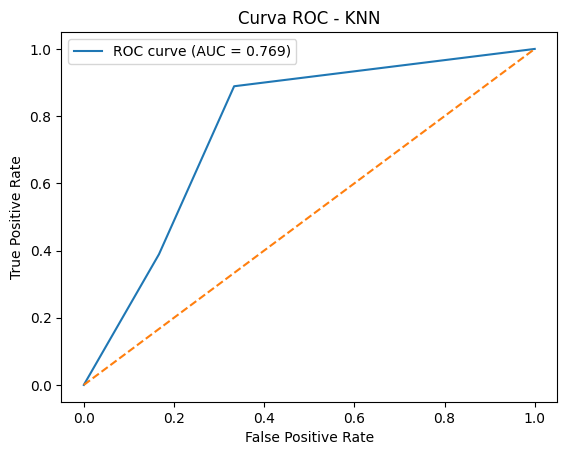

K=7, Threshold=0.5 → 0.8000

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.80      0.67      0.73        12
         1.0       0.80      0.89      0.84        18

    accuracy                           0.80        30
   macro avg       0.80      0.78      0.78        30
weighted avg       0.80      0.80      0.80        30

ROC AUC: 0.7685185185185185


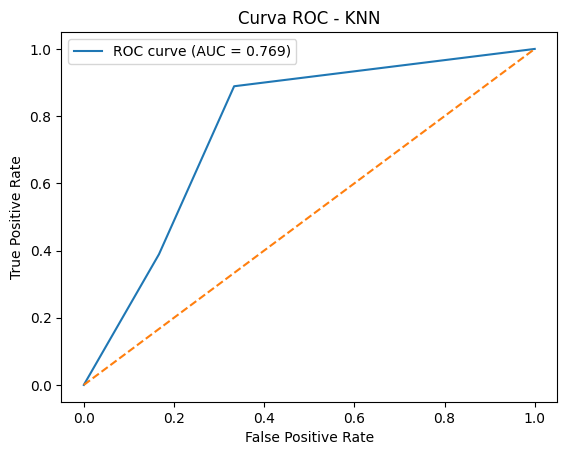

K=7, Threshold=0.55 → 0.8000

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.80      0.67      0.73        12
         1.0       0.80      0.89      0.84        18

    accuracy                           0.80        30
   macro avg       0.80      0.78      0.78        30
weighted avg       0.80      0.80      0.80        30



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc

for k in range(1, 21):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=3)),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights='uniform',   # depois testamos 'distance'
            metric='manhattan'
        ))
    ])
    
    model.fit(X_train, y_train)
    # y_pred = model.predict(X_test)
    # acc = accuracy_score(y_test, y_pred)
    # print("Accuracy:", acc)
    # print(f"k={k} → Accuracy: {acc:.4f}")

    # pega probabilidade da classe 1
    probs = model.predict_proba(X_test)[:, 1]

    for t in [0.4, 0.45, 0.5, 0.55, 0.6]: # testando diferentes thresholds para a classificação
        y_pred = (probs >= t).astype(int)
        acc = accuracy_score(y_test, y_pred)
        if acc >= 0.75:
            fpr, tpr, thresholds = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)
            print("ROC AUC:", roc_auc)
            # plot
            plt.figure()
            plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
            plt.plot([0, 1], [0, 1], linestyle='--')  # linha aleatória
            plt.xlabel("Taxa falso positivo")
            plt.ylabel("Taxa verdadeiro positivo")
            plt.title("Curva ROC - KNN")
            plt.legend()
            plt.show()
            print(f"K={k}, Threshold={t} → {acc:.4f}")
            print("\nRelatório de Classificação:\n")
            print(classification_report(y_test, y_pred))

Threshold é:

A régua que transforma probabilidade em decisão.

Baixo threshold → mais classe 1
Alto threshold → menos classe 1

__Variáveis de Tunning de KNN__:
* StandardScaler garante que todas as features estejam na mesma escala.
* PCA reduz o ruído, mas ao mesmo tempo pode eliminar informação relevante se colocar poucas componentes.
* KNN está capturando padrões de proximidade no espaço transformado pelo PCA.

## Gradient Boosting (sklearn)

In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Modelo
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Treino
gb.fit(x_train_scaled, y_train)

# Previsão
y_pred_gb = gb.predict(x_test_scaled)

# Avaliação
print("Accuracy GB:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy GB: 0.5666666666666667
              precision    recall  f1-score   support

         0.0       0.47      0.67      0.55        12
         1.0       0.69      0.50      0.58        18

    accuracy                           0.57        30
   macro avg       0.58      0.58      0.57        30
weighted avg       0.60      0.57      0.57        30



In [31]:
for lr in [0.01, 0.05, 0.1]:
    for depth in [2, 3]:
        gb = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=lr,
            max_depth=depth,
            random_state=42
        )
        gb.fit(x_train_scaled, y_train)
        acc = accuracy_score(y_test, gb.predict(x_test_scaled))
        print(f"lr={lr}, depth={depth} → {acc:.4f}")

lr=0.01, depth=2 → 0.6667
lr=0.01, depth=3 → 0.6667
lr=0.05, depth=2 → 0.6000
lr=0.05, depth=3 → 0.5667
lr=0.1, depth=2 → 0.6000
lr=0.1, depth=3 → 0.6000


## SVM (com scaler obrigatório)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        class_weight='balanced'
    ))
])

svm_model.fit(x_train_scaled, y_train)

y_pred_svm = svm_model.predict(x_test_scaled)

print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy SVM: 0.6
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        12
         1.0       0.60      1.00      0.75        18

    accuracy                           0.60        30
   macro avg       0.30      0.50      0.38        30
weighted avg       0.36      0.60      0.45        30



c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [33]:
for C in [0.1, 1, 10]:
    for gamma in ['scale', 0.01, 0.1]:
        svm_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel='rbf', C=C, gamma=gamma))
        ])
        
        svm_model.fit(x_train_scaled, y_train)
        acc = accuracy_score(y_test, svm_model.predict(x_test_scaled))
        
        print(f"C={C}, gamma={gamma} → {acc:.4f}")

C=0.1, gamma=scale → 0.6000
C=0.1, gamma=0.01 → 0.6000
C=0.1, gamma=0.1 → 0.6000
C=1, gamma=scale → 0.6000
C=1, gamma=0.01 → 0.6000
C=1, gamma=0.1 → 0.6000
C=10, gamma=scale → 0.5667
C=10, gamma=0.01 → 0.6000
C=10, gamma=0.1 → 0.5333


## Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf = RandomForestClassifier(n_estimators=5, max_depth = 2,  random_state=7) 

rf.fit(x_train_scaled, y_train) 
estimator = rf.estimators_
y_predito_random_forest = rf.predict(x_test_scaled)

# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y_test, y_predito_random_forest)) #relatório de validação das métrica de desempenho.

0.5666666666666667


# Conclusão
O objetivo deste trabalho foi desenvolver um modelo capaz de prever se o IBOVESPA apresentaria alta ou baixa no dia seguinte, utilizando técnicas de aprendizado de máquina aplicadas a dados históricos do mercado. Inicialmente, foi necessário definir corretamente a variável alvo (target), utilizando o retorno percentual do dia seguinte por meio da operação shift(-1), garantindo que o modelo utilizasse apenas informações disponíveis até o momento da previsão e evitando vazamento de dados.

A partir dessa definição, foram testados diferentes modelos de classificação, incluindo Regressão Logística e K-Nearest Neighbors (KNN), além da criação e avaliação de diversas variáveis explicativas, como retornos passados, volatilidade e o gap de abertura, buscando identificar quais contribuíam positivamente para o desempenho do modelo. Esse processo exploratório foi fundamental para compreender melhor a estrutura dos dados e ajustar gradualmente o conjunto de features utilizadas.

Nos testes iniciais, os modelos apresentaram acurácia próxima ao baseline de aproximadamente 60%, indicando desempenho semelhante a uma estratégia simples baseada na classe majoritária. No entanto, por meio da experimentação contínua, seleção de variáveis relevantes e ajustes nos hiperparâmetros dos modelos, foi possível melhorar gradualmente o desempenho obtido.

Dentre os modelos avaliados, o que apresentou melhor resultado foi o K-Nearest Neighbors (KNN) com k = 7 e threshold = 0.5, ou seja, considerando os 7 vizinhos mais próximos e classificando como alta quando a probabilidade estimada é maior ou igual a 50%. Esse modelo atingiu acurácia de 80% no conjunto de teste de 30 dias, superando significativamente o baseline e indicando que a abordagem baseada em similaridade entre observações históricas pode capturar padrões relevantes no comportamento de curto prazo do mercado.

É importante ressaltar que o conjunto de teste utilizado possui 30 observações, o que representa uma limitação do estudo e sugere cautela na generalização dos resultados. Ainda assim, os experimentos realizados demonstram que, por meio de um processo exploratório cuidadoso e da aplicação adequada de técnicas de aprendizado de máquina, é possível construir modelos capazes de identificar padrões preditivos mesmo em séries financeiras caracterizadas por alto nível de ruído e volatilidade.